# Breast Cancer Segmentation – Evaluation
## AI Project SS2026

<h2 style="color:#00838f">Evaluation of supervised model</h2>

Loads the trained model from `results/models/` and evaluates it
on the held-out "test patients".


### Quiet TensorFlow Logging
Silences TensorFlow's startup spam (the `I0000...` C++ info lines and Python
warnings) so the output stays readable. Must run before TensorFlow is imported.

In [7]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # hides TF C++ INFO/WARNING spam (the I0000... lines)

import tensorflow as tf
tf.get_logger().setLevel("ERROR")          # hides the Python-side TF warnings

### Setup & Paths
Imports and locates the three things this notebook needs: the chunks on the SSD,
the `split.json`, and the trained model - searched automatically in the repo.

In [1]:
import os, glob, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# --- paths: chunks on the SSD, split/model in the repo ---
CHUNK_DIR  = "/mnt/e/Advanced-MRI-Breast-Lesions/data/chunks_semisup"

def _find(name):
    hits = glob.glob(os.path.join("**", name), recursive=True)
    return os.path.abspath(hits[0]) if hits else None

SPLIT_FILE = _find("split.json")
MODEL_PATH = _find("attn_unet_supervised.keras")

print("split.json :", SPLIT_FILE)
print("model      :", MODEL_PATH)
print("chunks     :", len(glob.glob(os.path.join(CHUNK_DIR, "chunk_*.pkl"))))

2026-06-24 18:41:21.360800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 18:41:21.382121: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 18:41:21.388804: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 18:41:21.405264: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


split.json : /mnt/c/Users/Metiyan/Desktop/AI_Project/AI_Project/Processed_and_Split_data/split.json
model      : /mnt/c/Users/Metiyan/Desktop/AI_Project/AI_Project/results/models/attn_unet_supervised.keras
chunks     : 77


### Data Index
A standalone copy of the slice index (this notebook shares no memory with the
training notebook). Maps every slice to its chunk so test slices can be pulled
on demand, and lists the held-out test patients.

In [2]:
# Standalone copy of the slice index: maps every (patient, slice) to its chunk
# so we can pull test slices without loading the whole dataset.
class DataIndex:
    def __init__(self, chunk_dir=CHUNK_DIR, split_file=SPLIT_FILE):
        self.chunks = sorted(glob.glob(os.path.join(chunk_dir, "chunk_*.pkl")))
        with open(split_file) as f:
            self.split = json.load(f)
        self._chunk_id, self._row, self._pid, self._lesion = [], [], [], []
        self._cache_id = None; self._cache = None
        for ci, cf in enumerate(self.chunks):
            c = pickle.load(open(cf, "rb"))
            areas = c["masks"].reshape(len(c["masks"]), -1).sum(1)
            n = len(c["patient_ids"])
            self._chunk_id += [ci]*n
            self._row      += list(range(n))
            self._pid      += c["patient_ids"].tolist()
            self._lesion   += (areas > 0).tolist()
            del c
        self._chunk_id = np.array(self._chunk_id); self._row = np.array(self._row)
        self._pid = np.array(self._pid); self._lesion = np.array(self._lesion, bool)

    def _get_chunk(self, ci):
        if ci != self._cache_id:
            self._cache = pickle.load(open(self.chunks[ci], "rb")); self._cache_id = ci
        return self._cache

    def get_slice(self, gi):
        c = self._get_chunk(self._chunk_id[gi]); r = self._row[gi]
        return c["images"][r].astype(np.float32), c["masks"][r].astype(np.float32)

    def patient_slices(self, pid):
        # global indices of all slices belonging to one patient (in stored order)
        gi = np.where(self._pid == pid)[0]
        return gi[np.argsort(self._row[gi])]

idx = DataIndex()
test_patients = idx.split["test"]
print(f"test patients: {len(test_patients)}  -> {test_patients}")

test patients: 14  -> ['AMBL-004', 'AMBL-031', 'AMBL-038', 'AMBL-044', 'AMBL-045', 'AMBL-507', 'AMBL-559', 'AMBL-561', 'AMBL-565', 'AMBL-582', 'AMBL-597', 'AMBL-603', 'AMBL-604', 'AMBL-632']


### Load Trained Model
Loads the best saved model with `compile=False` (we only run inference, so the
custom loss isn't needed). `predict_prob` returns a per-pixel tumour probability map.

In [3]:
# The model was trained with a custom loss/metrics. To load it we must supply
# them — or load weights only with compile=False. We use compile=False and just
# run inference, so we don't even need the loss here.
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("model loaded:", model.input_shape, "->", model.output_shape)

def predict_prob(img):           # img: (H,W,1) float32 -> prob map (H,W)
    p = model.predict(img[None, ...], verbose=0)[0, ..., 0]
    return p.astype(np.float32)

I0000 00:00:1782319360.547595   29918 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:0a:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782319360.579286   29918 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:0a:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782319360.579349   29918 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:0a:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782319360.581257   29918 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:0a:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782319360.581305   29918 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:0a:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

model loaded: (None, 256, 256, 1) -> (None, 256, 256, 1)


### Per-Patient Evaluation
Runs the model on every test slice and computes Dice/IoU "per patient".
Reports two numbers: Dice on tumour slices only (the honest score) vs. Dice
including empty slices (the deflated value that explained the low training val-Dice).

In [4]:
THRESH = 0.5   # probability cutoff for the binary mask

def dice(gt, pr, eps=1e-6):
    gt = gt > 0.5; pr = pr > 0.5
    inter = (gt & pr).sum()
    return (2*inter + eps) / (gt.sum() + pr.sum() + eps)

def iou(gt, pr, eps=1e-6):
    gt = gt > 0.5; pr = pr > 0.5
    inter = (gt & pr).sum(); union = (gt | pr).sum()
    return (inter + eps) / (union + eps)

rows = []
# we also keep, per patient, the slice with the largest GT mask for later plots
best_slice = {}
for pid in test_patients:
    gis = idx.patient_slices(pid)
    d_les, d_all, gt_px, pr_px = [], [], 0, 0
    top_area, top = -1, None
    for k, gi in enumerate(gis):
        im, mk = idx.get_slice(gi)
        pr = predict_prob(im)
        gt2, pr2 = mk[..., 0], pr
        d = dice(gt2, pr2)
        d_all.append(d)
        if gt2.sum() > 0:                 # tumour slice -> the meaningful Dice
            d_les.append(d)
        gt_px += int(gt2.sum() > 0); pr_px += int((pr2 > THRESH).sum() > 0)
        if gt2.sum() > top_area:
            top_area = gt2.sum(); top = (gi, im, gt2, pr2)
    best_slice[pid] = top
    rows.append(dict(
        patient=pid, n_slices=len(gis),
        dice_lesion=np.mean(d_les) if d_les else np.nan,   # Dice on tumour slices only
        dice_all=np.mean(d_all),                           # Dice incl. empty slices
        n_lesion_slices=len(d_les),
    ))

res = pd.DataFrame(rows)
print(res.to_string(index=False))
print(f"\nMean Dice on tumour slices : {res.dice_lesion.mean():.3f}")
print(f"Mean Dice incl. empty      : {res.dice_all.mean():.3f}  (this is the deflated one)")

I0000 00:00:1782319366.033285   31304 service.cc:146] XLA service 0x74243c022dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782319366.033343   31304 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-24 18:42:46.057768: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-24 18:42:46.284470: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
I0000 00:00:1782319370.134828   31304 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 patient  n_slices  dice_lesion  dice_all  n_lesion_slices
AMBL-004       116 7.479112e-01  0.877065                5
AMBL-031       116 6.220386e-01  0.815299               17
AMBL-038       116 3.055580e-01  0.820642               17
AMBL-044       116 1.825258e-01  0.554118                7
AMBL-045       116 2.773784e-01  0.802165               11
AMBL-507       116 2.935482e-08  0.905172                4
AMBL-559       116 2.000000e-01  0.913793                5
AMBL-561       116 1.591057e-01  0.742360                7
AMBL-565       116 2.616038e-08  0.810345                8
AMBL-582       116 1.460635e-01  0.794750               15
AMBL-597       116 3.348493e-01  0.804885               22
AMBL-603       116 1.679678e-02  0.795131               14
AMBL-604       116 2.282644e-01  0.547508               11
AMBL-632       116 2.884618e-02  0.820955                8

Mean Dice on tumour slices : 0.232
Mean Dice incl. empty      : 0.786  (this is the deflated one)


### Dice Distribution
Shows the spread of Dice across test patients, not just a single mean - a more
honest picture of where the model does well and where it struggles.

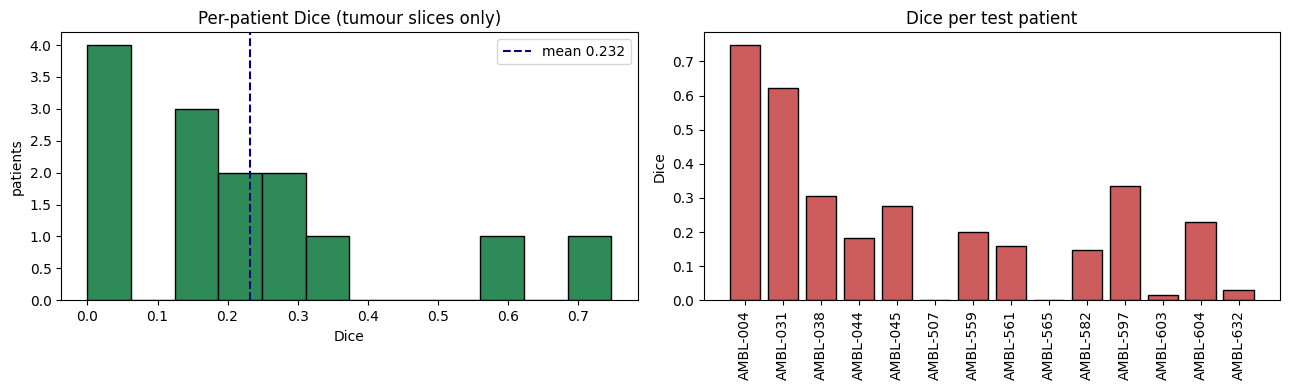

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(res.dice_lesion.dropna(), bins=12, color="seagreen", edgecolor="black")
ax[0].axvline(res.dice_lesion.mean(), color="navy", ls="--",
              label=f"mean {res.dice_lesion.mean():.3f}")
ax[0].set_title("Per-patient Dice (tumour slices only)")
ax[0].set_xlabel("Dice"); ax[0].set_ylabel("patients"); ax[0].legend()

ax[1].bar(res.patient, res.dice_lesion, color="indianred", edgecolor="black")
ax[1].set_title("Dice per test patient"); ax[1].set_ylabel("Dice")
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

### Heatmaps & Error Maps
For a few patients: image, ground truth, probability heatmap, and an error map
(green = correct, red = missed tumour, blue = false alarm). Shows not just how
much the model gets right, but "what kind" of mistakes it makes.

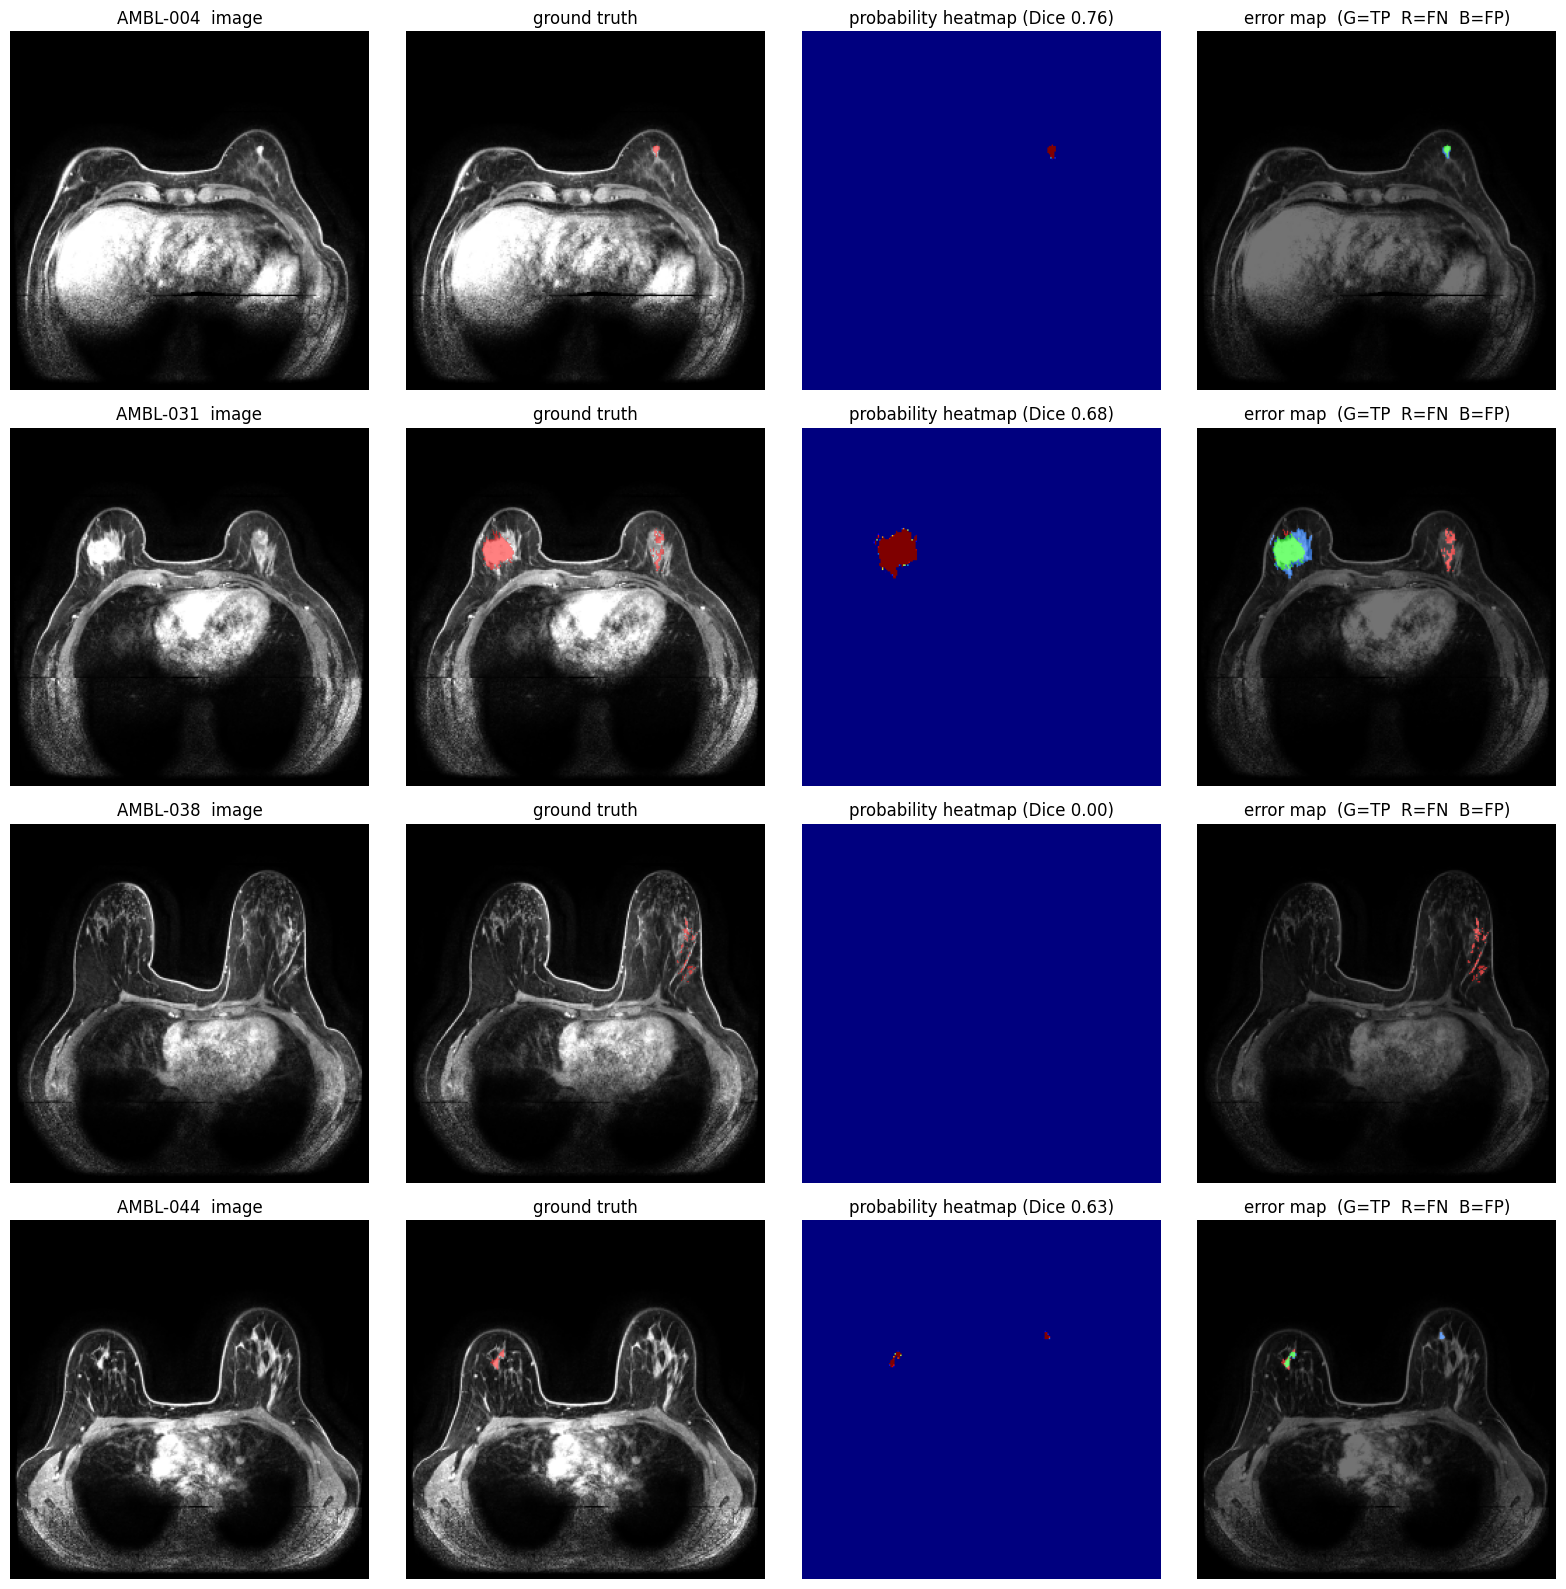

In [6]:
# For a few patients, show: image | ground truth | probability heatmap | error map
# error map: green = correct tumour (TP), red = missed (FN), blue = false alarm (FP)
def error_rgb(gt, pr):
    gt = gt > 0.5; pr = pr > THRESH
    rgb = np.zeros((*gt.shape, 3), np.float32)
    rgb[gt & pr]   = [0, 1, 0]   # true positive
    rgb[gt & ~pr]  = [1, 0, 0]   # false negative (missed tumour)
    rgb[~gt & pr]  = [0, 0.4, 1] # false positive
    return rgb

show = [p for p in test_patients if best_slice[p] is not None][:4]
fig, axes = plt.subplots(len(show), 4, figsize=(16, 4*len(show)))
if len(show) == 1: axes = axes[None, :]
for r, pid in enumerate(show):
    gi, im, gt, pr = best_slice[pid]
    g = im[..., 0]
    axes[r,0].imshow(g, cmap="gray");                axes[r,0].set_title(f"{pid}  image")
    axes[r,1].imshow(g, cmap="gray")
    axes[r,1].imshow(np.ma.masked_where(gt==0, gt), cmap="autumn", alpha=0.5)
    axes[r,1].set_title("ground truth")
    hm = axes[r,2].imshow(pr, cmap="jet", vmin=0, vmax=1)
    axes[r,2].set_title(f"probability heatmap (Dice {dice(gt,pr):.2f})")
    axes[r,3].imshow(g, cmap="gray"); axes[r,3].imshow(error_rgb(gt, pr), alpha=0.55)
    axes[r,3].set_title("error map  (G=TP  R=FN  B=FP)")
    for c in range(4): axes[r,c].axis("off")
plt.tight_layout(); plt.show()